In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
PROJECT_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(PROJECT_DIR, "Dataset", "Life Expectancy Data.csv")

FEATURES = [
    "HIV/AIDS",
    "Schooling",
    "Adult Mortality",
    "Income composition of resources",
    "under-five deaths",
    "infant deaths",
    "BMI",
    "GDP",
    "Diphtheria",
    "thinness 1-19 years"
]

df = pd.read_csv(DATA_PATH)

df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
df = df.dropna(subset=["Life expectancy"]).copy()

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2928, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [3]:
X = df[FEATURES]
y = df["Life expectancy"]

print("Features:")
print(FEATURES)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['HIV/AIDS', 'Schooling', 'Adult Mortality', 'Income composition of resources', 'under-five deaths', 'infant deaths', 'BMI', 'GDP', 'Diphtheria', 'thinness 1-19 years']

Feature shape: (2928, 10)
Target shape: (2928,)


In [4]:
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['HIV/AIDS', 'Schooling', 'Adult Mortality', 'Income composition of resources', 'under-five deaths', 'infant deaths', 'BMI', 'GDP', 'Diphtheria', 'thinness 1-19 years']
Categorical features: []


## Linear Regression

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred = linear_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Linear Regression Results
MAE: 2.9464359572567105
MSE: 15.98109676673278
RMSE: 3.997636397514509
R2 Score: 0.8152461596541918


In [6]:
os.makedirs(os.path.join(PROJECT_DIR, "model"), exist_ok=True)

joblib.dump(
    linear_pipeline,
    os.path.join(PROJECT_DIR, "model", "linear_regression_model.pkl")
)

print("Linear Regression model saved successfully.")

Linear Regression model saved successfully.


## Logistic Regression

In [7]:
X_class = df[FEATURES]
y_class = (df["Life expectancy"] >= 65).astype(int)

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

classification_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

params = {
    "classifier__C": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    classification_pipeline,
    params,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train_class, y_train_class)

print("Best parameters:", grid.best_params_)
print("Best cross-validation accuracy:", grid.best_score_)

Best parameters: {'classifier__C': 10}
Best cross-validation accuracy: 0.9376678876678877


In [8]:
logistic_model = grid.best_estimator_

y_pred_class = logistic_model.predict(X_test_class)

accuracy = accuracy_score(y_test_class, y_pred_class)

print("Logistic Regression Accuracy:", accuracy)
print("\nClassification Report:")
print(
    classification_report(
        y_test_class,
        y_pred_class,
        target_names=["Below 65", "65 and above"]
    )
)

Logistic Regression Accuracy: 0.9368600682593856

Classification Report:
              precision    recall  f1-score   support

    Below 65       0.90      0.88      0.89       170
65 and above       0.95      0.96      0.96       416

    accuracy                           0.94       586
   macro avg       0.93      0.92      0.92       586
weighted avg       0.94      0.94      0.94       586



Confusion Matrix:
[[150  20]
 [ 17 399]]


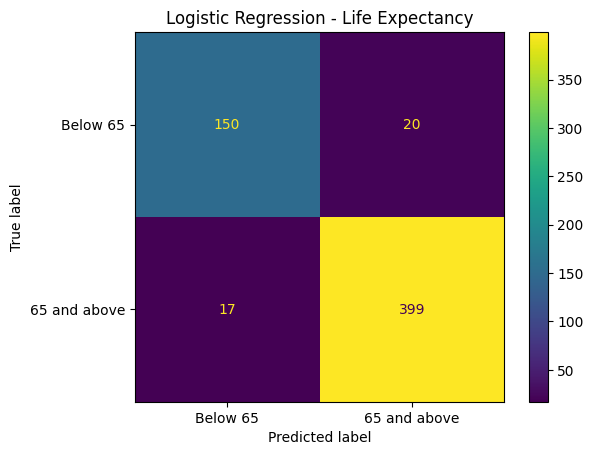

In [9]:
cm = confusion_matrix(y_test_class, y_pred_class)

print("Confusion Matrix:")
print(cm)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Below 65", "65 and above"]
)

display.plot()
plt.title("Logistic Regression - Life Expectancy")
plt.show()

In [10]:
joblib.dump(
    logistic_model,
    os.path.join(PROJECT_DIR, "model", "logistic_regression_model.pkl")
)

print("Logistic Regression model saved successfully.")
print("Models are saved in the model folder.")

Logistic Regression model saved successfully.
Models are saved in the model folder.
